# Graph Sparsification Experiments

Systematic comparison of **Metric Backbone (MBB)**, **Metric Backbone Rescaled (MBBr)**,
**Effective Resistance**, and **heat-kernel gradient descent (HeatK-GD)** sparsification
across configuration models with various degree and weight distributions.

HeatK-GD (diagonal heat-kernel matching, hard top-`m` + STE, proximity rescaling) requires **PyTorch** (`pip install torch`).

**Weight conventions:**
- Generators produce **distance** weights (costs in (0, ∞])
- MBB is computed on **distances**
- MBBr rescales the MBB proximities so their sum matches the original graph
- EffR and SIR use **proximity** weights (in [0, 1]), converted via `proximity = 1/(distance+1)`

Beta is auto-calibrated for each graph so that the SIR epidemic is in an interesting regime.

In [1]:
import sys, os
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(repo_root, 'src', 'python')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [2]:
import numpy as np
from scipy import sparse
import matplotlib.pyplot as plt
import time

from graph_sparsification.generators import configuration_model
from graph_sparsification.sparsifiers import (
    metric_backbone,
    metric_backbone_rescaled,
    effective_resistance_sparsify,
    to_proximity,
    to_distance,
)
from graph_sparsification.sir import sir_monte_carlo, calibrate_beta
from graph_sparsification.visualization import (
    detect_communities,
    plot_adjacency_comparison,
    plot_multi_infection_comparison,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

try:
    from graph_sparsification._sir_cpp import sir_simulation_cpp
    print('C++ SIR backend: available')
except ImportError:
    print('C++ SIR backend: NOT available (using Python fallback)')

try:
    from graph_sparsification.heat_kernel_gd import heat_kernel_gd_sparsify
    _HAS_HEATK_GD = True
except ImportError:
    heat_kernel_gd_sparsify = None
    _HAS_HEATK_GD = False
    print('Heat-kernel GD: NOT available (install torch, e.g. pip install torch)')

C++ SIR backend: available


## 1. Distribution definitions

In [3]:
# ── Degree distributions ──────────────────────────────────────────────

degree_distributions = {
    'Unif(1,50)':  lambda n, rng: rng.integers(1, 51, size=n),
    'Unif(1,100)': lambda n, rng: rng.integers(1, 101, size=n),
    'Exp(30)':     lambda n, rng: np.ceil(rng.exponential(30, size=n)).astype(int),
    'Exp(60)':     lambda n, rng: np.ceil(rng.exponential(60, size=n)).astype(int),
    'LogN(3.26,0.66)': lambda n, rng: np.ceil(rng.lognormal(3.26, 0.66, size=n)).astype(int),
    'LogN(3.26,2)':    lambda n, rng: np.ceil(rng.lognormal(3.26, 2.0, size=n)).astype(int),
    'Pareto(2.5,20)':  lambda n, rng: np.ceil((rng.pareto(2.5, size=n) + 1) * 20).astype(int),
    'Pareto(1.5,30)':  lambda n, rng: np.ceil((rng.pareto(1.5, size=n) + 1) * 30).astype(int),
}

# ── Weight (distance/cost) distributions ──────────────────────────────

weight_distributions = {
    'Exp(1/30)':       lambda m, rng: rng.exponential(30.0, size=m),   # scale = 1/rate
    'Exp(1)':          lambda m, rng: rng.exponential(1.0, size=m),
    'Exp(30)':         lambda m, rng: rng.exponential(1/30, size=m),
    'LogN(2,1)':       lambda m, rng: rng.lognormal(2.0, 1.0, size=m),
    'LogLogN(1.2,0.4)': lambda m, rng: np.exp(rng.lognormal(1.2, 0.4, size=m)),
    'LogLogN(1.2,0.8)': lambda m, rng: np.exp(rng.lognormal(1.2, 0.8, size=m)),
    'LogLogN(2,0.8)':   lambda m, rng: np.exp(rng.lognormal(2.0, 0.8, size=m)),
}

print(f'{len(degree_distributions)} degree distributions × {len(weight_distributions)} weight distributions')
print(f'= {len(degree_distributions) * len(weight_distributions)} configurations')

8 degree distributions × 7 weight distributions
= 56 configurations


## 2. Experiment parameters

In [4]:
N_NODES = 500          # nodes per graph
N_SIR_RUNS = 500       # Monte Carlo SIR runs per graph
N_CAL_RUNS = 30        # calibration runs (fewer, for speed)
PATIENT_ZERO = 0.01    # percentage of patient zeros
GAMMA = 1.0            # recovery rate
HEATK_GD_STEPS = 120   # GD steps (paper uses 300; increase for tighter fit)
HEATK_GD_LR = 0.1
# Heat-kernel time t is set per graph as t = GAMMA / beta (see heat_kernel_gd_sparsify).
SEED = 42

## 3. Main loop


Unif(1,50)  |  Exp(1/30)
  edges=6111, deg: mean=24.4 med=24 max=50, dist: mean=31.59 med=21.81, prox: mean=0.0957
  iter  1: beta=1.000000, mean_inf=0.496, std=0.181
  -> Converged: beta=1.000000
  MBB:  1319 edges (21.6%) [0.4s]
  MBBr: 1319 edges (21.6%) [0.3s]  (scale=1.54x)
  EffR: 1319 edges (21.6%) [0.2s]
  HeatK-GD: 1319 edges (21.6%) [51.1s]  (m_keep=1319, t=gamma/beta=1, final_loss=8.5859e+00)


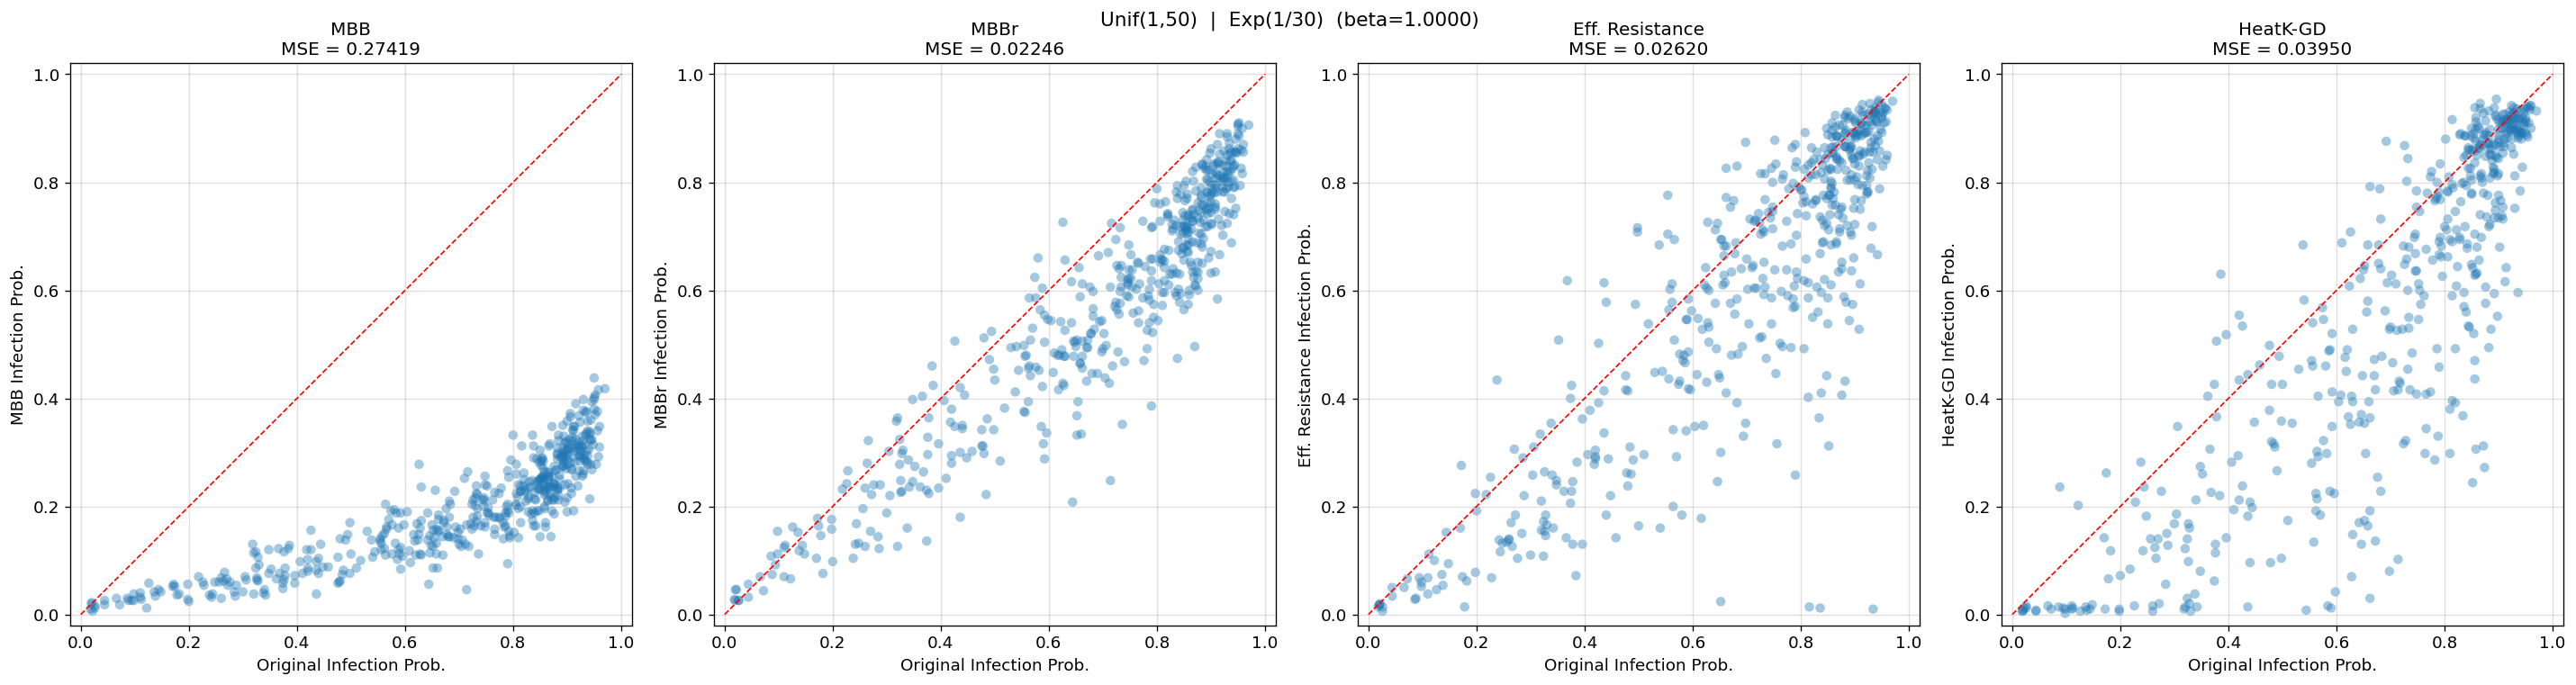


Unif(1,50)  |  Exp(1)
  edges=6111, deg: mean=24.4 med=24 max=50, dist: mean=1.05 med=0.73, prox: mean=0.5866
  iter  1: beta=1.000000, mean_inf=0.903, std=0.107
  iter  2: beta=0.500050, mean_inf=0.902, std=0.152
  iter  3: beta=0.250075, mean_inf=0.739, std=0.189
  iter  4: beta=0.125087, mean_inf=0.506, std=0.195
  -> Converged: beta=0.125087
  MBB:  1319 edges (21.6%) [0.2s]
  MBBr: 1319 edges (21.6%) [0.3s]  (scale=3.10x)
  EffR: 1319 edges (21.6%) [0.3s]
  HeatK-GD: 1319 edges (21.6%) [78.8s]  (m_keep=1319, t=gamma/beta=7.994, final_loss=1.8972e-02)


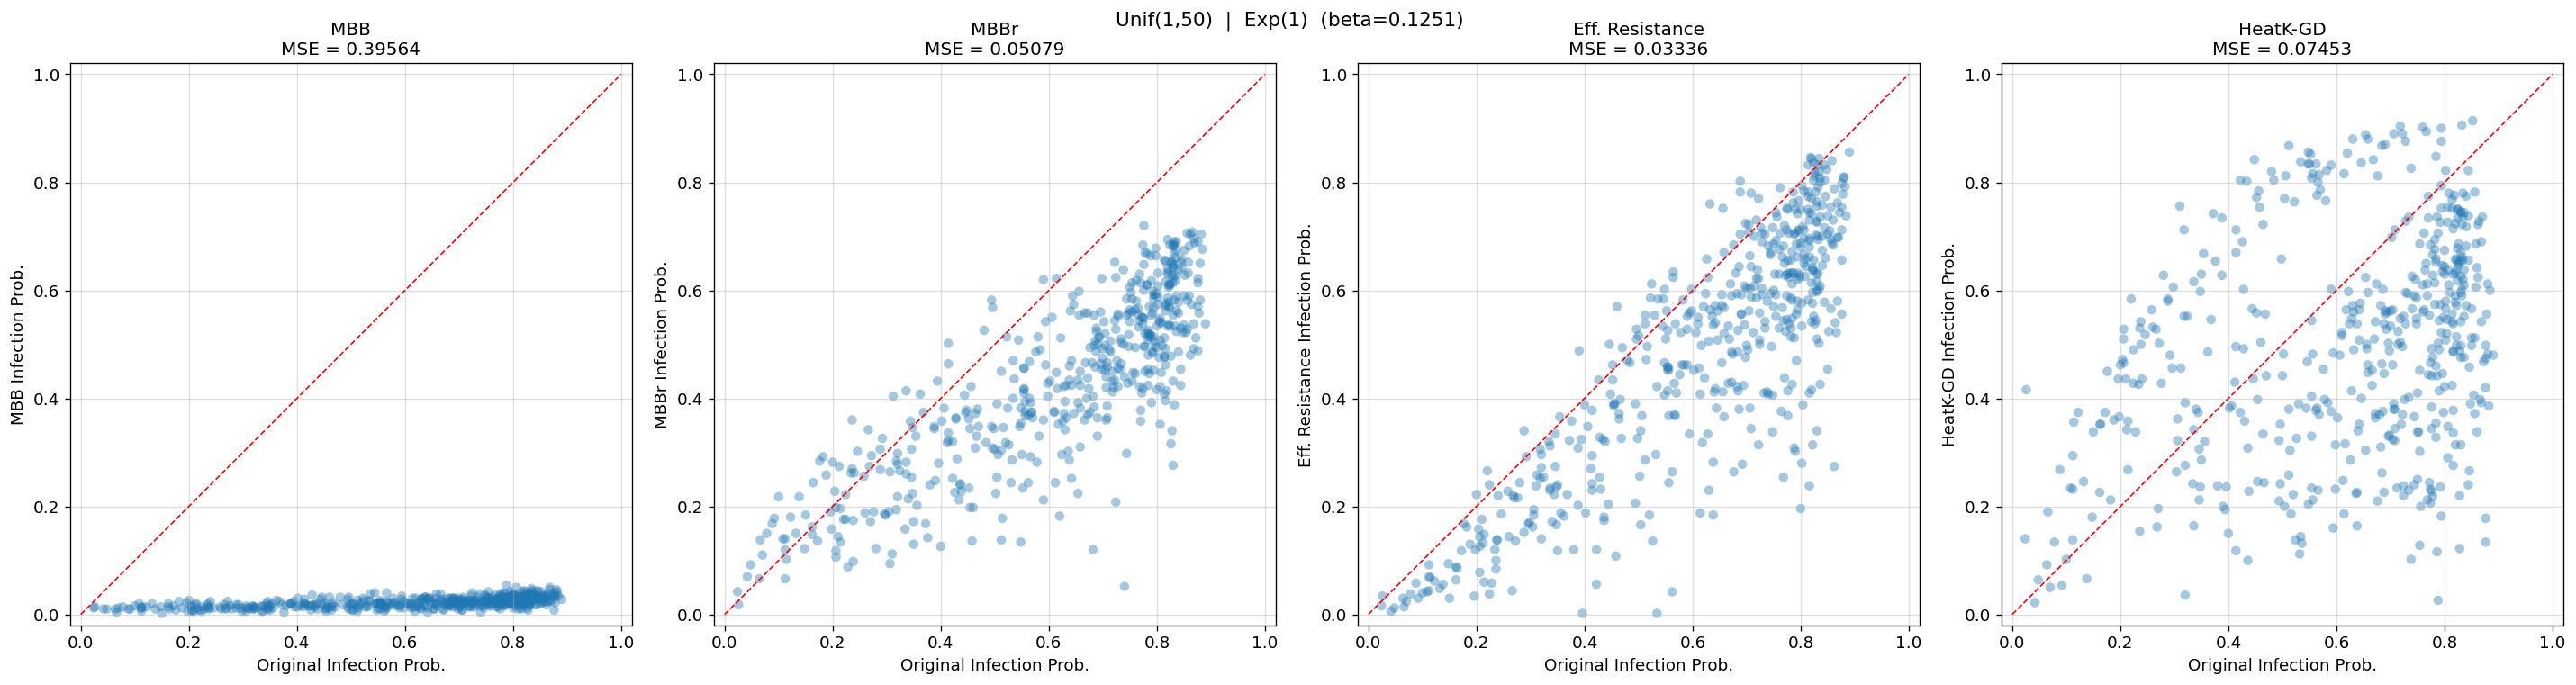


Unif(1,50)  |  Exp(30)
  edges=6111, deg: mean=24.4 med=24 max=50, dist: mean=0.04 med=0.02, prox: mean=0.9671
  iter  1: beta=1.000000, mean_inf=0.916, std=0.072
  iter  2: beta=0.500050, mean_inf=0.929, std=0.119
  iter  3: beta=0.250075, mean_inf=0.827, std=0.153
  iter  4: beta=0.125087, mean_inf=0.710, std=0.203
  iter  5: beta=0.062594, mean_inf=0.197, std=0.099
  iter  6: beta=0.093841, mean_inf=0.641, std=0.217
  iter  7: beta=0.078217, mean_inf=0.451, std=0.173
  -> Converged: beta=0.078217
  MBB:  1319 edges (21.6%) [0.2s]
  MBBr: 1319 edges (21.6%) [0.2s]  (scale=4.50x)
  EffR: 1319 edges (21.6%) [0.2s]


KeyboardInterrupt: 

In [5]:
run_seed = 42

all_results = []
master_rng = np.random.default_rng(SEED)

for deg_name, deg_sampler in degree_distributions.items():
    for wt_name, wt_sampler in weight_distributions.items():
        label = f'{deg_name}  |  {wt_name}'
        rng = np.random.default_rng(run_seed)

        # ── Generate graph (distance weights) ─────────────────────────
        W_dist = configuration_model(N_NODES, deg_sampler, wt_sampler, rng=rng)
        n_edges = sparse.triu(W_dist).nnz

        if n_edges < 10:
            print(f'SKIP {label}: only {n_edges} edges')
            continue

        degrees = np.diff(W_dist.indptr)
        dist_weights = W_dist.data

        # Convert to proximity for EffR and SIR
        W_prox = to_proximity(W_dist)

        print(f'\n{"="*72}')
        print(f'{label}')
        print(f'  edges={n_edges}, '
              f'deg: mean={degrees.mean():.1f} med={np.median(degrees):.0f} max={degrees.max()}, '
              f'dist: mean={dist_weights.mean():.2f} med={np.median(dist_weights):.2f}, '
              f'prox: mean={W_prox.data.mean():.4f}')

        # ── Calibrate beta (on proximity graph) ──────────────────────
        beta, cal_info = calibrate_beta(
            W_prox, gamma=GAMMA,
            n_calibration_runs=N_CAL_RUNS, rng=rng, verbose=True,
        )

        # ── Sparsify ──────────────────────────────────────────────────

        # MBB (on distances)
        t0 = time.time()
        W_mbb_dist = metric_backbone(W_dist)
        t_mbb = time.time() - t0
        n_mbb = sparse.triu(W_mbb_dist).nnz
        W_mbb_prox = to_proximity(W_mbb_dist)  # convert for SIR

        # MBBr (MBB rescaled — already returns proximity weights)
        t0 = time.time()
        W_mbbr_prox = metric_backbone_rescaled(W_dist)
        t_mbbr = time.time() - t0
        n_mbbr = sparse.triu(W_mbbr_prox).nnz  # same sparsity as MBB

        # MBBr rescaling factor
        mbbr_scale = W_prox.data.sum() / W_mbb_prox.data.sum() if W_mbb_prox.data.sum() > 0 else np.nan

        # EffR (on proximities, exact same edge count as MBB)
        t0 = time.time()
        W_effr_prox = effective_resistance_sparsify(W_prox, n_edges=n_mbb, rng=rng)
        t_effr = time.time() - t0
        n_effr = sparse.triu(W_effr_prox).nnz

        print(f'  MBB:  {n_mbb} edges ({n_mbb/n_edges*100:.1f}%) [{t_mbb:.1f}s]')
        print(f'  MBBr: {n_mbbr} edges ({n_mbbr/n_edges*100:.1f}%) [{t_mbbr:.1f}s]  '
              f'(scale={mbbr_scale:.2f}x)')
        print(f'  EffR: {n_effr} edges ({n_effr/n_edges*100:.1f}%) [{t_effr:.1f}s]')

        # Heat-kernel GD sparsifier (same edge budget m as MBB / EffR)
        W_hkgd_prox = None
        t_hkgd = float('nan')
        n_hkgd = 0
        hkgd_info = {}
        if _HAS_HEATK_GD and n_mbb > 0:
            t0 = time.time()
            try:
                # Same undirected edge budget as MBB / EffR (triu nnz counts each edge once)
                m_keep = max(1, min(int(n_mbb), sparse.triu(W_prox, k=1).nnz))
                W_hkgd_prox, hkgd_info = heat_kernel_gd_sparsify(
                    W_prox,
                    m=m_keep,
                    beta=beta,
                    gamma=GAMMA,
                    n_steps=HEATK_GD_STEPS,
                    lr=HEATK_GD_LR,
                    rng_seed=int(rng.integers(0, 2**31 - 1)),
                    return_history=False,
                )
                t_hkgd = time.time() - t0
                n_hkgd = sparse.triu(W_hkgd_prox, k=1).nnz
                fl = hkgd_info.get('final_loss', float('nan'))
                tk = hkgd_info.get('t', float('nan'))
                print(f'  HeatK-GD: {n_hkgd} edges ({n_hkgd/n_edges*100:.1f}%) [{t_hkgd:.1f}s]  '
                      f'(m_keep={m_keep}, t=gamma/beta={tk:.4g}, final_loss={fl:.4e})')
            except Exception as e:
                print(f'  HeatK-GD: FAILED ({e})')
                W_hkgd_prox = None
        elif not _HAS_HEATK_GD:
            print('  HeatK-GD: skipped (no torch)')

        # ── SIR Monte Carlo (all on proximity graphs) ─────────────────
        sir_orig = sir_monte_carlo(W_prox,      beta, GAMMA, PATIENT_ZERO, n_runs=N_SIR_RUNS, rng=rng)
        sir_mbb  = sir_monte_carlo(W_mbb_prox,  beta, GAMMA, PATIENT_ZERO, n_runs=N_SIR_RUNS, rng=rng)
        sir_mbbr = sir_monte_carlo(W_mbbr_prox, beta, GAMMA, PATIENT_ZERO, n_runs=N_SIR_RUNS, rng=rng)
        sir_effr = sir_monte_carlo(W_effr_prox, beta, GAMMA, PATIENT_ZERO, n_runs=N_SIR_RUNS, rng=rng)
        if W_hkgd_prox is not None:
            sir_hkgd = sir_monte_carlo(W_hkgd_prox, beta, GAMMA, PATIENT_ZERO, n_runs=N_SIR_RUNS, rng=rng)
        else:
            sir_hkgd = None

        # ── Plots ─────────────────────────────────────────────────────
        # Detect communities on proximity graph (high weight = strong link)
        #communities = detect_communities(W_prox)
        #fig = plot_adjacency_comparison(W_dist, W_mbb_dist,
        #                                labels=('Original (dist)', 'Metric Backbone (dist)'),
        #                                communities=communities)
        #fig.suptitle(label, fontsize=13, y=1.02)
        #plt.show()

        sp_probs = [sir_mbb['infection_prob'], sir_mbbr['infection_prob'], sir_effr['infection_prob']]
        sp_labels = ['MBB', 'MBBr', 'Eff. Resistance']
        if sir_hkgd is not None:
            sp_probs.append(sir_hkgd['infection_prob'])
            sp_labels.append('HeatK-GD')

        fig = plot_multi_infection_comparison(
            sir_orig['infection_prob'],
            sp_probs,
            sp_labels,
        )
        fig.suptitle(f'{label}  (beta={beta:.4f})', fontsize=13, y=1.02)
        plt.show()

        ## Marginal distributions of node infection probabilities (density)
        #fig2, axd = plt.subplots(figsize=(9, 4.5))
        #bins = np.linspace(0, 1, 36)
        #axd.hist(sir_orig['infection_prob'], bins=bins, alpha=0.35, density=True, label='Original', color='black')
        #for ps, lab in zip(sp_probs, sp_labels):
        #    axd.hist(ps, bins=bins, alpha=0.30, density=True, label=lab)
        #axd.set_xlabel('Node infection probability')
        #axd.set_ylabel('Density')
        #axd.set_title(f'{label} — infection probability distributions')
        #axd.legend(fontsize=9)
        #axd.set_xlim(0, 1)
        #fig2.tight_layout()
        #plt.show()

        # ── Store result ──────────────────────────────────────────────
        def _mse(po, ps):
            m = np.isfinite(po) & np.isfinite(ps)
            return np.mean((po[m] - ps[m])**2)

        def _r2(po, ps):
            m = np.isfinite(po) & np.isfinite(ps)
            po, ps = po[m], ps[m]
            ss_tot = np.sum((po - po.mean())**2)
            return 1 - np.sum((po - ps)**2) / ss_tot if ss_tot > 0 else 0.0

        all_results.append({
            'deg': deg_name, 'wt': wt_name, 'label': label,
            'n_edges': n_edges, 'beta': beta,
            'mbb_pct': n_mbb / n_edges * 100,
            'mbbr_pct': n_mbbr / n_edges * 100,
            'effr_pct': n_effr / n_edges * 100,
            'mbbr_scale': mbbr_scale,
            'mse_mbb':  _mse(sir_orig['infection_prob'], sir_mbb['infection_prob']),
            'mse_mbbr': _mse(sir_orig['infection_prob'], sir_mbbr['infection_prob']),
            'mse_effr': _mse(sir_orig['infection_prob'], sir_effr['infection_prob']),
            'r2_mbb':  _r2(sir_orig['infection_prob'], sir_mbb['infection_prob']),
            'r2_mbbr': _r2(sir_orig['infection_prob'], sir_mbbr['infection_prob']),
            'r2_effr': _r2(sir_orig['infection_prob'], sir_effr['infection_prob']),
            'mean_inf_orig': sir_orig['infection_prob'].mean(),
            'hkgd_pct': (n_hkgd / n_edges * 100) if n_hkgd else float('nan'),
            'mse_hkgd': (_mse(sir_orig['infection_prob'], sir_hkgd['infection_prob'])
                         if sir_hkgd is not None else float('nan')),
            'r2_hkgd': (_r2(sir_orig['infection_prob'], sir_hkgd['infection_prob'])
                        if sir_hkgd is not None else float('nan')),
            'hkgd_time': t_hkgd,
            'hkgd_final_loss': float(hkgd_info.get('final_loss', float('nan'))),
            'hkgd_t': float(hkgd_info.get('t', float('nan'))),
        })

## 4. Summary table

In [ ]:
print(f"{'Degree':<18} {'Weights':<18} {'edges':>6} {'beta':>8} "
      f"{'MBB%':>6} {'MBBr%':>6} {'EffR%':>6} {'R² MBB':>7} {'R² MBBr':>8} {'R² EffR':>8}")
print('-' * 110)
for r in all_results:
    print(f"{r['deg']:<18} {r['wt']:<18} {r['n_edges']:>6} {r['beta']:>8.4f} "
          f"{r['mbb_pct']:>5.1f}% {r['mbbr_pct']:>5.1f}% {r['effr_pct']:>5.1f}% "
          f"{r['r2_mbb']:>7.3f} {r['r2_mbbr']:>8.3f} {r['r2_effr']:>8.3f}")

Degree             Weights             edges     beta   MBB%  MBBr%  EffR%  R² MBB  R² MBBr  R² EffR
--------------------------------------------------------------------------------------------------------------
Unif(1,50)         Exp(1/30)            6111   1.5625  21.6%  21.6%  21.6%  -0.960    0.775    0.616
Unif(1,50)         Exp(1)               6111   0.2032  21.6%  21.6%  21.6% -12.102    0.216    0.395
Unif(1,50)         Exp(30)              6111   0.0938  21.6%  21.6%  21.6%  -9.310   -0.242    0.427
Unif(1,50)         LogN(2,1)            6111   0.8750  42.1%  42.1%  42.1%   0.444    0.957    0.902
Unif(1,50)         LogLogN(1.2,0.4)     6111   3.2500  43.9%  43.9%  43.9%   0.833    0.918    0.890
Unif(1,50)         LogLogN(1.2,0.8)     6111   1.2812  33.3%  33.3%  33.3%   0.538    0.915    0.881
Unif(1,50)         LogLogN(2,0.8)       6111   7.7500  18.3%  18.3%  18.3%   0.765    0.930    0.810
Unif(1,100)        Exp(1/30)           11563   1.0000  11.3%  11.3%  11.3%  -3.24

## 5. Heatmaps by configuration

Per-configuration heatmaps for: MBBr rescaling factor, percentage of edges preserved, and MSE of infection probabilities for each method (including **HeatK-GD** when PyTorch is installed), HeatK-GD edge retention (%), and optional MSE comparisons.

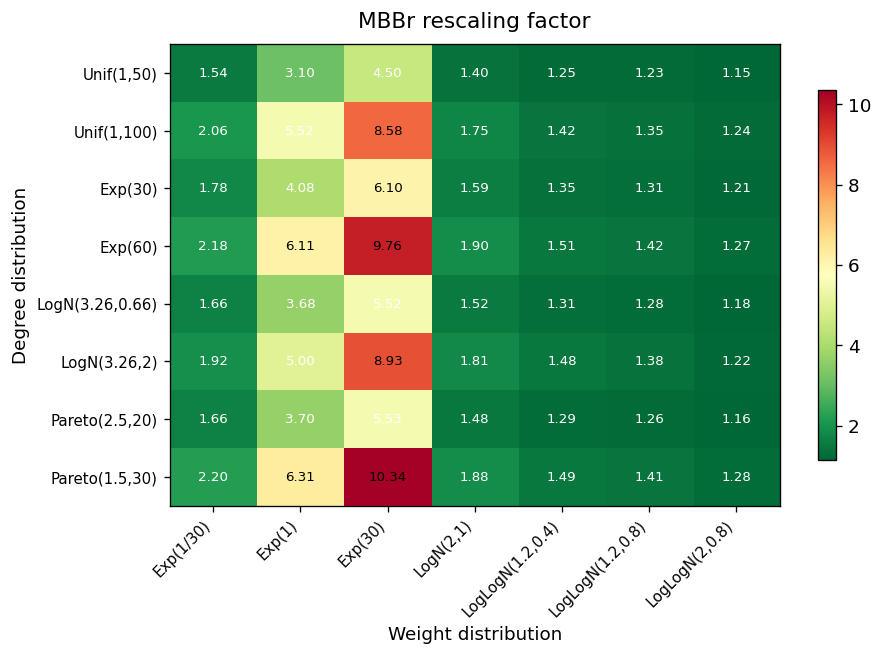

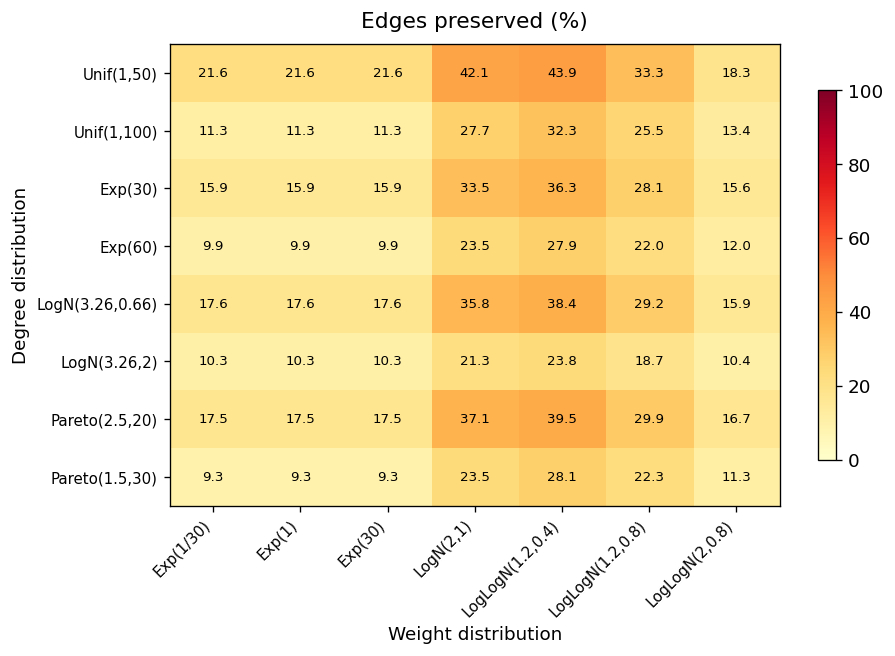

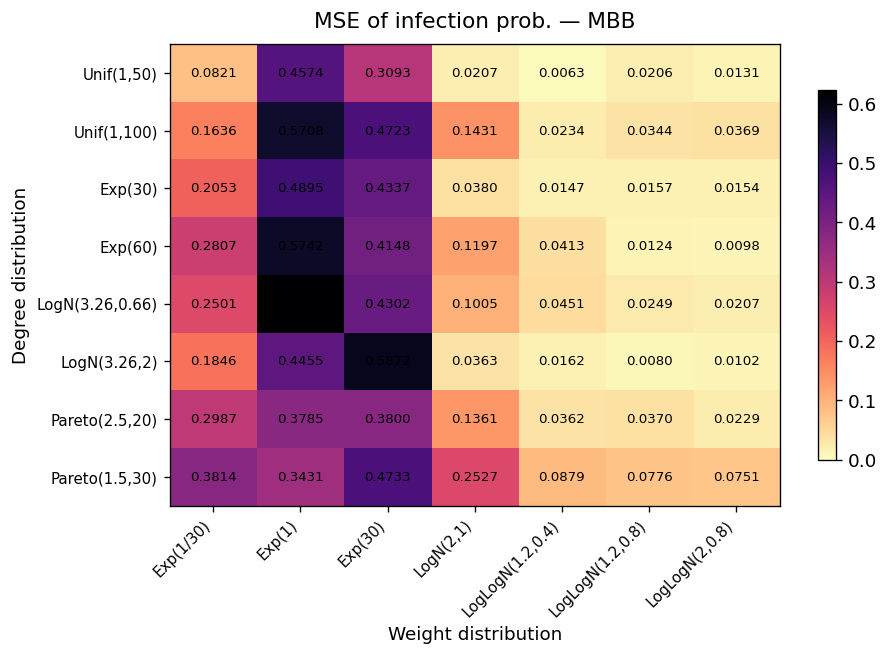

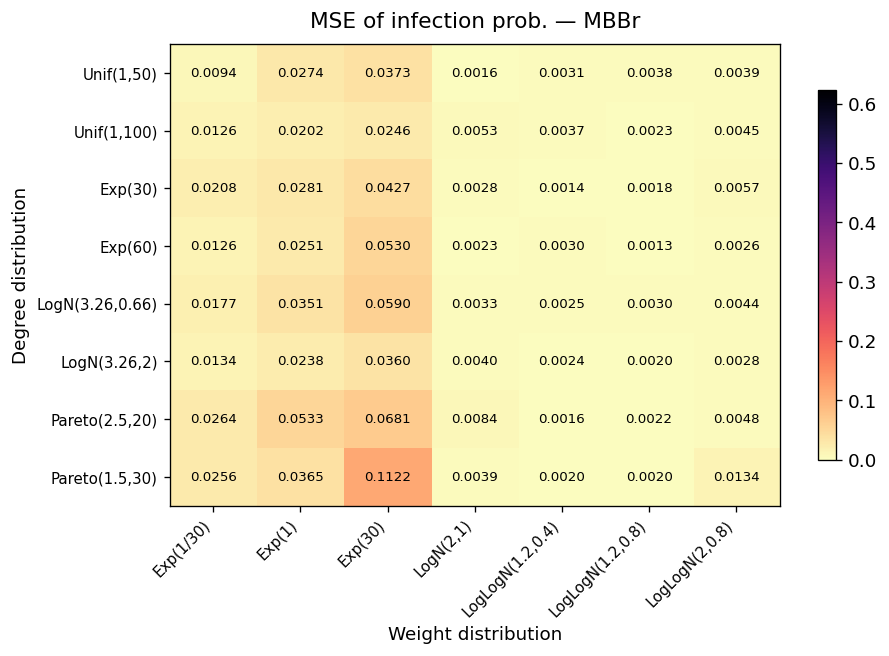

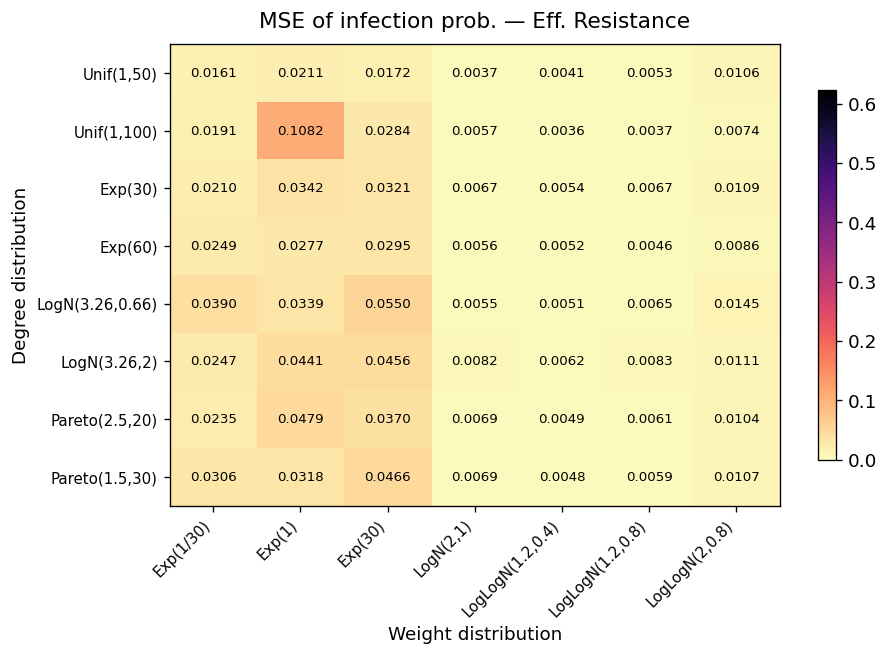

In [ ]:
deg_names = list(degree_distributions.keys())
wt_names  = list(weight_distributions.keys())
n_deg, n_wt = len(deg_names), len(wt_names)

# Build lookup from results
res_lookup = {(r['deg'], r['wt']): r for r in all_results}

def _build_grid(key):
    grid = np.full((n_deg, n_wt), np.nan)
    for i, d in enumerate(deg_names):
        for j, w in enumerate(wt_names):
            if (d, w) in res_lookup:
                grid[i, j] = res_lookup[(d, w)][key]
    return grid

def _plot_heatmap(grid, title, cmap='viridis', fmt='.2f', vmin=None, vmax=None,
                  annot_color=None):
    fig, ax = plt.subplots(figsize=(max(8, n_wt * 1.1), max(4, n_deg * 0.7)))
    im = ax.imshow(grid, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(n_wt))
    ax.set_xticklabels(wt_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(n_deg))
    ax.set_yticklabels(deg_names, fontsize=9)
    ax.set_xlabel('Weight distribution', fontsize=11)
    ax.set_ylabel('Degree distribution', fontsize=11)
    ax.set_title(title, fontsize=13, pad=10, color='black')
    ax.tick_params(colors='black')
    # Annotate cells
    for i in range(n_deg):
        for j in range(n_wt):
            val = grid[i, j]
            if np.isfinite(val):
                if annot_color is not None:
                    color = annot_color
                else:
                    color = 'white' if im.norm(val) < 0.5 else 'black'
                ax.text(j, i, f'{val:{fmt}}', ha='center', va='center',
                        fontsize=8, color=color)
    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    return fig

# ── 1. MBBr rescaling factor ─────────────────────────────────────────
grid_scale = _build_grid('mbbr_scale')
fig = _plot_heatmap(grid_scale, 'MBBr rescaling factor', cmap='RdYlGn_r')
plt.show()

# ── 2. Percentage of edges preserved (MBB / MBBr / EffR share MBB topology) ─
grid_pct = _build_grid('mbb_pct')
fig = _plot_heatmap(grid_pct, 'Edges preserved (%) — MBB / MBBr / EffR', cmap='YlOrRd', fmt='.1f',
                    vmin=0, vmax=100, annot_color='black',)
plt.show()

# ── 2b. HeatK-GD edge retention (% of original edges) ───────────────
grid_pct_hkgd = _build_grid('hkgd_pct')
fig = _plot_heatmap(grid_pct_hkgd, 'Edges preserved (%) — HeatK-GD', cmap='YlOrRd', fmt='.1f',
                    vmin=0, vmax=100, annot_color='black',)
plt.show()

# ── 3. MSE heatmaps per method ───────────────────────────────────────
grid_mse_mbb  = _build_grid('mse_mbb')
grid_mse_mbbr = _build_grid('mse_mbbr')
grid_mse_effr = _build_grid('mse_effr')
grid_mse_hkgd = _build_grid('mse_hkgd')

# Shared color scale across MSE heatmaps
all_mse = np.concatenate([
    grid_mse_mbb.ravel(), grid_mse_mbbr.ravel(), grid_mse_effr.ravel(), grid_mse_hkgd.ravel(),
])
mse_max = np.nanmax(all_mse)
if not np.isfinite(mse_max):
    mse_max = 1.0

for grid, name in [
    (grid_mse_mbb, 'MBB'),
    (grid_mse_mbbr, 'MBBr'),
    (grid_mse_effr, 'Eff. Resistance'),
    (grid_mse_hkgd, 'HeatK-GD'),
]:
    fig = _plot_heatmap(grid, f'MSE of infection prob. — {name}',
                        cmap='magma_r', fmt='.4f', vmin=0, vmax=mse_max)
    plt.show()

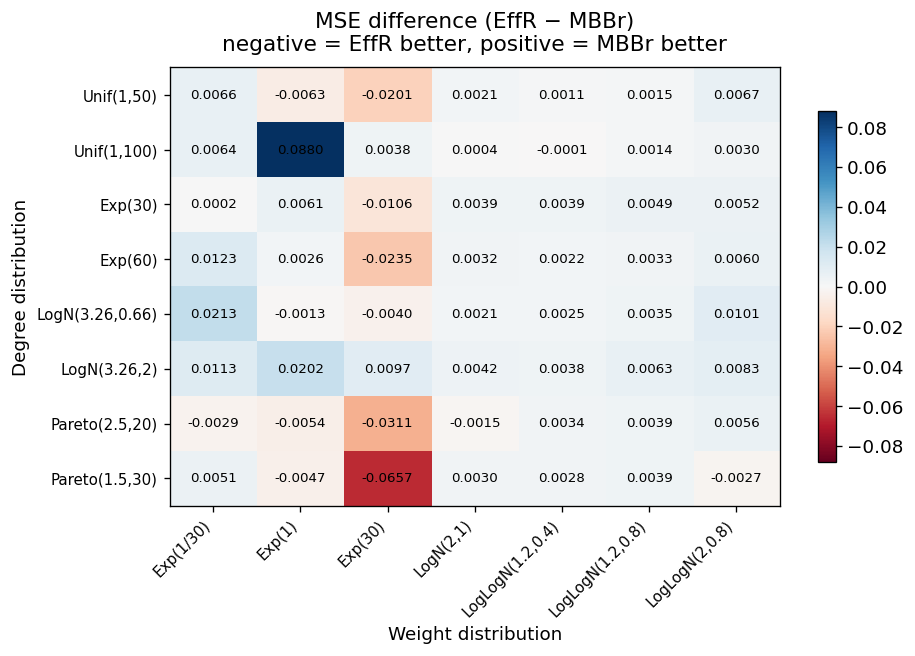

In [ ]:
# ── 4. MSE difference: EffR − MBBr (negative = EffR better) ──────────
grid_diff = grid_mse_effr - grid_mse_mbbr
vabs = np.nanmax(np.abs(grid_diff))
fig = _plot_heatmap(
    grid_diff,
    'MSE difference (EffR − MBBr)\nnegative = EffR better, positive = MBBr better',
    cmap='RdBu', fmt='.4f', vmin=-vabs, vmax=vabs,
    annot_color='black',
)
plt.show()

# ── 5. MSE difference: HeatK-GD − MBBr ─────────────────────────────
grid_diff_hkgd = grid_mse_hkgd - grid_mse_mbbr
vabs2 = np.nanmax(np.abs(grid_diff_hkgd))
if np.isfinite(vabs2) and vabs2 > 0:
    fig = _plot_heatmap(
        grid_diff_hkgd,
        'MSE difference (HeatK-GD − MBBr)\nnegative = MBBr better',
        cmap='RdBu', fmt='.4f', vmin=-vabs2, vmax=vabs2,
        annot_color='black',
    )
    plt.show()

